In [2]:
!python --version

Python 3.14.3


The system cannot find the path specified.


# ___iTOL___
-----------------

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [31]:
data = pd.read_csv(r"../../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")
data.insert(loc=0, column="leaf_ID", value=range(1, data.shape[0]+1))
data

,leaf_ID,binominal,F01286,F01287,F01289,F01290,F00056,F00004,F00679,F00727,state
0,1,Rudbeckia_hirta,Rudbeckia,hirta,Asteraceae,Asterales,NaN,"Poon GT, Maherali H. 2015. Competitive interac...",-1.332792,5.694268,AM
1,2,Ratibida_pinnata,Ratibida,pinnata,Asteraceae,Asterales,NaN,"Craine JM, Froehle J, Tilman DG, Wedin DA, Cha...",-0.820981,4.025352,AM
2,3,Heliopsis_helianthoides,Heliopsis,helianthoides,Asteraceae,Asterales,NaN,"Craine JM, Froehle J, Tilman DG, Wedin DA, Cha...",-0.967584,4.158883,NM
3,4,Liatris_aspera,Liatris,aspera,Asteraceae,Asterales,NaN,"Craine JM, Froehle J, Tilman DG, Wedin DA, Cha...",-0.798508,4.382027,AM
4,5,Arnica_sororia,Arnica,sororia,Asteraceae,Asterales,NaN,"Kembel SW, Cahill JF, Jr. 2011. Independent Ev...",-1.413460,4.342257,AM
...,...,...,...,...,...,...,...,...,...,...,...
990,991,Dicranopteris_linearis,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,1.0,"Kong DL, Wang JJ, Kardol P, Wu HF, Zeng H, Den...",-1.625567,4.318821,AM
991,992,Osmunda_japonica,Osmunda,japonica,Osmundaceae,Osmundales,1.0,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",-0.870421,3.157944,AM
992,993,Equisetum_hyemale,Equisetum,hyemale,Equisetaceae,Equisetales,1.0,"Dong X, Wang H, Gu J, Wang Y, Wang Z. 2014. Ro...",-0.736703,4.454201,NMAM
993,994,Equisetum_pratense,Equisetum,pratense,Equisetaceae,Equisetales,1.0,"Dong X, Wang H, Gu J, Wang Y, Wang Z. 2014. Ro...",-1.413391,5.540389,NMAM


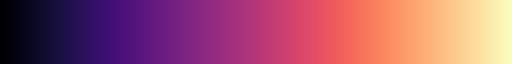

In [15]:
colormaps.get_cmap("magma")

In [33]:
# tip lebels - iTOL leaf IDs
order_ranges = data.groupby("F01290").agg({"leaf_ID": lambda x: (x.min(), x.max())})
order_ranges

,leaf_ID
F01290,
Apiales,"(107, 126)"
Aquifoliales,"(136, 139)"
Arecales,"(822, 825)"
Asparagales,"(712, 722)"
Asterales,"(1, 106)"
Brassicales,"(549, 555)"
Canellales,"(897, 897)"
Caryophyllales,"(269, 282)"
Celastrales,"(543, 548)"


In [38]:
order_ranges.shape

(48, 1)

In [56]:
np.unique(np.random.randint(low=0, high=255, size=(100, 3)), axis=1)[:4]

array([[ 75,  92, 209],
       [211,   5,   0],
       [195, 158,   1],
       [  5, 248, 196]], dtype=int32)

In [75]:
colours = np.unique(np.random.randint(low=0, high=255, size=(100, 3)), axis=1)[:order_ranges.shape[0]]
with open(file=r"./TREE_COLORS.txt", mode="wt") as fp:
    for (llim, ulim), (r, g, b) in zip(order_ranges.leaf_ID, colours):
        fp.write(f"{llim}|{ulim} range rgba({r}, {g}, {b}, 0.5)\n")